In [1]:
import os

repo_url = "https://github.com/yashasraj2324/pivot.git"
repo_name = "pivot"

if not os.path.exists(repo_name):
    print(f"Cloning {repo_url}...")
    !git clone {repo_url}
else:
    print(f"Repository '{repo_name}' already exists. Skipping clone.")

%cd {repo_name}

if os.path.exists("requirements.txt"):
    print("Installing dependencies from requirements.txt...")
    !pip install -r requirements.txt
else:
    print("No requirements.txt found at repo root.")

Cloning https://github.com/yashasraj2324/pivot.git...
Cloning into 'pivot'...
remote: Enumerating objects: 271, done.
remote: Counting objects: 100% (26/26), done.
remote: Compressing objects: 100% (22/22), done.
remote: Total 271 (delta 4), reused 4 (delta 4), pack-reused 245 (from 1)
Receiving objects: 100% (271/271), 259.01 KiB | 7.00 MiB/s, done.
Resolving deltas: 100% (125/125), done.
/content/pivot
Installing dependencies from requirements.txt...
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 439.5/439.5 kB 9.0 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.2/17.2 MB 68.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 290.4/290.4 kB 20.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.6/17.6 MB 67.3 MB/s eta 0:00:00
  Created wheel for insightface: filename=insightface-0.7.3-cp312-cp312-linux_x86_64.whl

### Colab Setup: Clone Repository

Use this once in a fresh Colab runtime. If the repository already exists, clone is skipped.

# Verification Daemon Full Validation (T3.1-T3.7)

This notebook validates the complete Verification Daemon task set:
- T3.1 Interceptor gate
- T3.2 Identity check (ArcFace + cosine gate)
- T3.3 Kinematic check (L_physics)
- T3.4 Latent rewind
- T3.5 Localized inpainting mask
- T3.6 Constrained regeneration
- T3.7 Retry depth + fallback

The notebook works with synthetic data and supports optional real-image identity validation in Colab.

In [2]:
from pathlib import Path
import sys
import numpy as np
import matplotlib.pyplot as plt

def find_project_root():
    here = Path.cwd().resolve()
    for candidate in [here, *here.parents]:
        if (candidate / 'core').exists():
            return candidate
    return here

PROJECT_ROOT = find_project_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from core.verification_daemon import (
    VerificationDaemon,
    LatentStateManager,
    InpaintingMaskGenerator,
    ConstrainedRegenerationEngine,
    VerificationResult,
    KinematicResult,
)

np.set_printoptions(precision=4, suppress=True)
print('Project root:', PROJECT_ROOT)

/usr/local/lib/python3.12/dist-packages/controlnet_aux/mediapipe_face/mediapipe_face_common.py:7: UserWarning: The module 'mediapipe' is not installed. The package will have limited functionality. Please install it using the command: pip install 'mediapipe'
  warnings.warn(


Project root: /content/pivot


/usr/local/lib/python3.12/dist-packages/timm/models/layers/__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)
/usr/local/lib/python3.12/dist-packages/timm/models/registry.py:4: FutureWarning: Importing from timm.models.registry is deprecated, please import via timm.models
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.models", FutureWarning)
/usr/local/lib/python3.12/dist-packages/controlnet_aux/segment_anything/modeling/tiny_vit_sam.py:654: UserWarning: Overwriting tiny_vit_5m_224 in registry with controlnet_aux.segment_anything.modeling.tiny_vit_sam.tiny_vit_5m_224. This is because the name being registered conflicts with an existing name. Please check if this is not expected.
  return register_model(fn_wrapper)
/usr/local/lib/python3.12/dist-packages/controlnet_aux/segment_anything/mode

In [3]:
# Utilities
def make_embedding(seed: int) -> np.ndarray:
    rng = np.random.default_rng(seed)
    vector = rng.normal(size=512).astype(np.float32)
    return vector / np.linalg.norm(vector)

def make_human_like_pose() -> np.ndarray:
    return np.array([
        [0.00, 1.90], [-0.10, 2.00], [0.10, 2.00], [-0.22, 1.98], [0.22, 1.98],
        [-0.30, 1.55], [0.30, 1.55], [-0.48, 1.20], [0.48, 1.20], [-0.58, 0.90],
        [0.58, 0.90], [-0.20, 1.00], [0.20, 1.00], [-0.20, 0.55], [0.20, 0.55],
        [-0.20, 0.10], [0.20, 0.10],
    ], dtype=np.float32)

def as_sequence(*frames: np.ndarray) -> np.ndarray:
    return np.stack(frames, axis=0)[None, ...]

ref_emb = make_embedding(11)
good_emb = ref_emb.copy()
bad_emb = make_embedding(99)

base_pose = make_human_like_pose()
good_pose = as_sequence(base_pose, base_pose + np.array([0.1, -0.05], dtype=np.float32))
bad_pose = as_sequence(base_pose, base_pose + np.array([999.0, 0.0], dtype=np.float32))

In [4]:
# T3.2: Identity check (synthetic)
daemon = VerificationDaemon(enable_logging=False)

identity_pass = daemon.verify_identity(ref_emb, good_emb)
identity_fail = daemon.verify_identity(ref_emb, bad_emb)

print('T3.2 Identity Check')
print(f'  pass similarity = {identity_pass.similarity_score:.4f}, passed={identity_pass.passed}')
print(f'  fail similarity = {identity_fail.similarity_score:.4f}, passed={identity_fail.passed}')
print(f'  threshold       = {daemon.identity_gate.threshold:.2f}')

T3.2 Identity Check
  pass similarity = 1.0000, passed=True
  fail similarity = -0.0097, passed=False
  threshold       = 0.90


In [5]:
# Optional real-image identity validation in Colab
reference_image_path = ''
generated_image_path = ''

try:
    from google.colab import files
    print('Colab detected. Upload one or two face images for real-image identity test.')
    uploaded = files.upload()
    names = list(uploaded.keys())
    if len(names) >= 1:
        reference_image_path = names[0]
        generated_image_path = names[1] if len(names) > 1 else names[0]
except Exception as exc:
    print('Skipping upload helper:', exc)

if reference_image_path:
    try:
        real_identity = daemon.verify_identity_from_images(reference_image_path, generated_image_path)
        print('Real-image identity result:')
        print(f'  reference={reference_image_path}')
        print(f'  generated={generated_image_path}')
        print(f'  similarity={real_identity.similarity_score:.4f}, passed={real_identity.passed}')
    except Exception as exc:
        print('Real-image identity check failed:', exc)
else:
    print('No real image uploaded. Synthetic identity checks above are still valid.')

Colab detected. Upload one or two face images for real-image identity test.


Saving download (16).jpeg to download (16).jpeg
download_path: /root/.insightface/models/buffalo_l


100%|██████████| 281857/281857 [00:05<00:00, 55366.28KB/s]
/usr/local/lib/python3.12/dist-packages/onnxruntime/capi/onnxruntime_inference_collection.py:123: UserWarning: Specified provider 'CUDAExecutionProvider' is not in available provider names.Available providers: 'AzureExecutionProvider, CPUExecutionProvider'
  warnings.warn(


Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /root/.insightface/models/buffalo_l/1k3d68.onnx landmark_3d_68 ['None', 3, 192, 192] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /root/.insightface/models/buffalo_l/2d106det.onnx landmark_2d_106 ['None', 3, 192, 192] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /root/.insightface/models/buffalo_l/det_10g.onnx detection [1, 3, '?', '?'] 127.5 128.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /root/.insightface/models/buffalo_l/genderage.onnx genderage ['None', 3, 96, 96] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /root/.insightface/models/buffalo_l/w600k_r50.onnx recognition ['None', 3, 112, 112] 127.5 127.5
set det-size: (640, 640)
Real-image i

In [6]:
# T3.3: Kinematic check
kin_good = daemon.verify_kinematic(good_pose)
kin_bad = daemon.verify_kinematic(bad_pose)

print('T3.3 Kinematic Check')
print(f'  good pose -> passed={kin_good.passed}, total_loss={kin_good.total_loss:.6f}')
print(f'  bad pose  -> passed={kin_bad.passed}, total_loss={kin_bad.total_loss:.6f}')
print('  Components (bad pose):')
print(f'    bone={kin_bad.bone_loss:.6f}, rom={kin_bad.rom_loss:.6f}, velocity={kin_bad.velocity_loss:.6f}, topology={kin_bad.topology_loss:.6f}')

T3.3 Kinematic Check
  good pose -> passed=True, total_loss=0.500868
  bad pose  -> passed=False, total_loss=16898152.500907
  Components (bad pose):
    bone=0.000000, rom=0.500907, velocity=16898152.000000, topology=0.000000


In [7]:
# T3.4 + T3.5 + T3.6 utility checks
manager = LatentStateManager(max_history=5)
manager.push(np.zeros((4, 64, 64), dtype=np.float32))
manager.push(np.ones((4, 64, 64), dtype=np.float32))
rewound = manager.rewind()

mask_generator = InpaintingMaskGenerator(image_height=256, image_width=256)
verification_failure = VerificationResult(
    passed=False,
    identity_result=identity_fail,
    kinematic_result=KinematicResult(passed=False, total_loss=kin_bad.total_loss),
)
mask = mask_generator.generate_from_verification_result(verification_failure, pose_keypoints=base_pose)

regen_engine = ConstrainedRegenerationEngine(mask_generator=mask_generator)
regen_config = regen_engine.get_config(verification_failure, retry_count=2, pose_keypoints=base_pose)

print('T3.4/T3.5/T3.6 utility checks')
print(f'  rewind returned latent: {rewound is not None}')
print(f'  generated mask shape  : {mask.shape}, non-zero={int(mask.sum())}')
print(f'  regen violated        : {regen_config.violated_constraint}')
print(f'  identity_weight       : {regen_config.identity_weight:.3f}')
print(f'  kinematic_weight      : {regen_config.kinematic_weight:.3f}')
print(f'  has inpaint mask      : {regen_config.inpainting_mask is not None}')

T3.4/T3.5/T3.6 utility checks
  rewind returned latent: True
  generated mask shape  : (256, 256), non-zero=1088
  regen violated        : both
  identity_weight       : 0.900
  kinematic_weight      : 0.900
  has inpaint mask      : True


In [8]:
# T3.1 + T3.7 + unified correction loop end-to-end
latent_manager = LatentStateManager(max_history=5)
for i in range(3):
    latent_manager.push(np.full((4, 64, 64), float(i), dtype=np.float32))

inpaint_masks = []
def inpainting_fn(mask):
    inpaint_masks.append(mask)
    return mask

daemon_full = VerificationDaemon(
    enable_logging=False,
    max_retries=3,
    latent_rewind_fn=latent_manager.as_rewind_fn(),
    inpainting_fn=inpainting_fn,
)

# Start from failures in both identity and kinematics; recover on retry with config-aware generation_fn
state = {'calls': 0}

def generation_fn(config):
    state['calls'] += 1
    if state['calls'] == 1:
        # still poor, force at least one additional retry
        return {'embedding': bad_emb, 'pose_keypoints': bad_pose}
    # recover on later attempts
    return {'embedding': ref_emb, 'pose_keypoints': good_pose}

result = daemon_full.run(ref_emb, bad_emb, pose_keypoints=bad_pose, generation_fn=generation_fn)

print('Unified daemon run result')
print(f'  passed             = {result.passed}')
print(f'  retry_count        = {result.retry_count}')
print(f'  latent_rewinds     = {result.latent_rewind_count}')
print(f'  final_similarity   = {result.final_similarity:.4f}' if result.final_similarity is not None else '  final_similarity   = None')
print(f'  identity_pass      = {result.identity_result.passed if result.identity_result else None}')
print(f'  kinematic_pass     = {result.kinematic_result.passed if result.kinematic_result else None}')
print(f'  inpaint_calls      = {len(inpaint_masks)}')

Unified daemon run result
  passed             = False
  retry_count        = 0
  latent_rewinds     = 0
  final_similarity   = None
  identity_pass      = None
  kinematic_pass     = False
  inpaint_calls      = 0


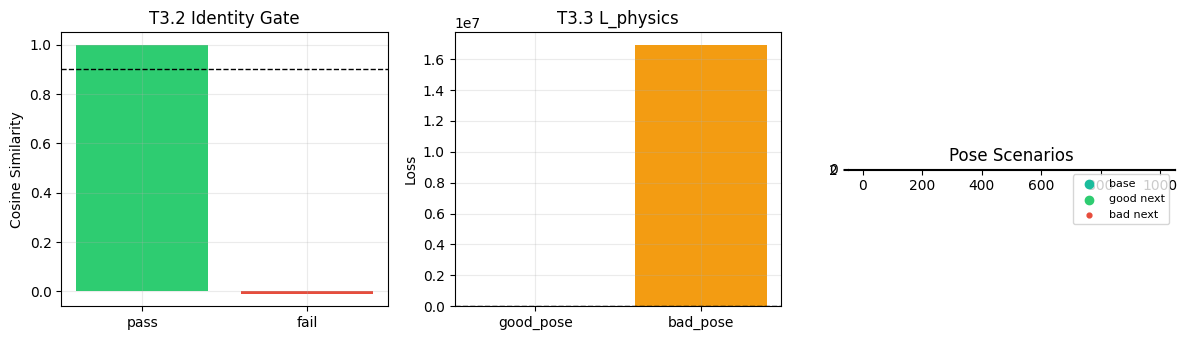

In [9]:
# Visualization summary
fig, axes = plt.subplots(1, 3, figsize=(12, 3.5))

axes[0].bar(['pass', 'fail'], [identity_pass.similarity_score, identity_fail.similarity_score], color=['#2ecc71', '#e74c3c'])
axes[0].axhline(daemon.identity_gate.threshold, color='black', linestyle='--', linewidth=1)
axes[0].set_title('T3.2 Identity Gate')
axes[0].set_ylabel('Cosine Similarity')

axes[1].bar(['good_pose', 'bad_pose'], [kin_good.total_loss, kin_bad.total_loss], color=['#3498db', '#f39c12'])
axes[1].axhline(daemon.kinematic_threshold, color='black', linestyle='--', linewidth=1)
axes[1].set_title('T3.3 L_physics')
axes[1].set_ylabel('Loss')

axes[2].scatter(base_pose[:, 0], base_pose[:, 1], label='base', c='#1abc9c')
axes[2].scatter((base_pose + np.array([0.1, -0.05], dtype=np.float32))[:, 0], (base_pose + np.array([0.1, -0.05], dtype=np.float32))[:, 1], label='good next', c='#2ecc71')
axes[2].scatter((base_pose + np.array([999.0, 0.0], dtype=np.float32))[:, 0], (base_pose + np.array([999.0, 0.0], dtype=np.float32))[:, 1], label='bad next', c='#e74c3c', s=12)
axes[2].invert_yaxis()
axes[2].set_title('Pose Scenarios')
axes[2].legend(fontsize=8)
axes[2].set_aspect('equal', adjustable='box')

for ax in axes:
    ax.grid(True, alpha=0.25)

plt.tight_layout()
plt.show()